# Fusión multimodal — TabNet + TFT + Bio_ClinicalBERT

Cuaderno del modelo de fusión multimodal del TFM. Integra las representaciones de los
tres codificadores especializados, entrenados en los cuadernos 07–09 y cargados aquí
**congelados** (no se reentrenan):

```
tab  ← TabNet.encoder(x_99)          [32]   (cuaderno 07)
tft  ← SepsisTFT.encode(seq, static) [64]   (cuaderno 08)
bert ← Bio_ClinicalBERT [CLS]        [768]  (cuaderno 09)
```

La fusión emplea **cross-modal attention direccional** (estilo MulT): para cada modalidad A,
la *query* procede de A y las *keys/values* de las otras dos.

```
tab_enriched  = CrossAttn(Q=tab,  K/V=[tft, bert])
tft_enriched  = CrossAttn(Q=tft,  K/V=[tab, bert])
bert_enriched = CrossAttn(Q=bert, K/V=[tab, tft])
```

Al final del cuaderno se incluye la **ablación de la rama tabular**: la misma red, con
idénticos hiperparámetros y semilla, entrenada con el vector de 99 características sin
comprimir en lugar de la representación del codificador de TabNet.


In [1]:
import os
# GPU habilitada (CUDA 12.8): ya no se oculta el dispositivo

import polars as pl
import numpy as np
import json
import pickle
from pathlib import Path
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

MIMIC    = Path.home() / "mimic-iv-3.0"
HOSP     = MIMIC / "hosp"
PROC     = Path("../data/processed")
TFT_DIR  = Path("../experiments/tft")
BERT_DIR = Path("../experiments/clinicalbert")
TABNET_DIR = Path("../experiments/tabnet")
OUT_DIR  = Path("../experiments/fusion_multimodal")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 24

torch.manual_seed(SEED)
np.random.seed(SEED)

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

print(f"Device: {DEVICE}")

Device: cuda


## Preparación de datos
Cohorte Sepsis-3, horizontes de predicción (6h y 12h) y características tabulares:
las mismas 99 variables de ventana con las que se entrenaron XGBoost y TabNet.

In [2]:
log("Cargando cohorte ...")
cohort = pl.read_parquet(PROC / "cohort.parquet").select(
    ["subject_id", "stay_id", "los_hours", "sepsis"]
)
splits = pl.read_parquet(PROC / "splits.parquet").select(["stay_id", "split"])
cohort = cohort.join(splits, on="stay_id", how="left")
vitals_meta = (
    pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                    columns=["stay_id", "onset_hour"])
    .unique(subset=["stay_id"])
)
cohort = cohort.join(vitals_meta, on="stay_id", how="left")
patients = pl.read_csv(
    HOSP / "patients.csv.gz", columns=["subject_id", "gender", "anchor_age"]
).with_columns((pl.col("gender") == "M").cast(pl.Int8).alias("male"))
cohort = cohort.join(
    patients.select(["subject_id", "anchor_age", "male"]), on="subject_id", how="left"
)

def assign_ref_hour(cohort, horizon, seed):
    rng = np.random.default_rng(seed)
    out = []
    for r in cohort.to_dicts():
        if r["sepsis"] == 1:
            ref = (int(r["onset_hour"]) - horizon) if r["onset_hour"] is not None else None
        else:
            lo, hi = 24, int(r["los_hours"]) - horizon
            ref = int(rng.integers(lo, hi + 1)) if hi >= lo else None
        if ref is not None and ref >= 12:
            r["ref_hour"] = ref
            out.append(r)
    return pl.DataFrame(out)

cohort_6h  = assign_ref_hour(cohort, 6,  SEED)
cohort_12h = assign_ref_hour(cohort, 12, SEED + 1)
print(f"Stays válidos 6h: {len(cohort_6h):,}  |  12h: {len(cohort_12h):,}")

[17:40:31] Cargando cohorte ...


Stays válidos 6h: 53,453  |  12h: 47,219


In [3]:
log("Cargando vitales y labs ...")
VITAL_COLS = ["heart_rate", "resp_rate", "spo2", "map", "temp_c", "fio2", "gcs_total"]
LAB_COLS   = ["platelet", "bilirubin", "creatinine", "lactate", "wbc",
              "hemoglobin", "sodium", "potassium", "glucose",
              "bicarbonate", "bun", "albumin", "inr", "ph", "pao2"]
vitals = pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                         columns=["stay_id", "hours_from_intime"] + VITAL_COLS)
labs   = pl.read_parquet(PROC / "labs/labs_hourly.parquet",
                         columns=["stay_id", "hours_from_intime"] + LAB_COLS)

def window_stats(data, ref, value_cols):
    windowed = (
        data.join(ref.select(["stay_id", "ref_hour"]), on="stay_id", how="inner")
        .filter(
            (pl.col("hours_from_intime") <= pl.col("ref_hour")) &
            (pl.col("hours_from_intime") >= pl.col("ref_hour") - 24)
        ).sort("hours_from_intime")
    )
    agg = []
    for c in value_cols:
        if c not in windowed.columns: continue
        agg += [
            pl.col(c).last().alias(f"{c}_last"),
            pl.col(c).mean().alias(f"{c}_mean"),
            (pl.col(c).last() - pl.col(c).first()).alias(f"{c}_trend"),
            (pl.col(c).max() - pl.col(c).min()).alias(f"{c}_range"),
        ]
    return windowed.group_by("stay_id").agg(agg)

def extract_features(cohort_h):
    vf = window_stats(vitals, cohort_h, VITAL_COLS)
    lf = window_stats(labs,   cohort_h, LAB_COLS)
    qsofa = (
        vf.select(["stay_id", "resp_rate_last", "map_last", "gcs_total_last"])
        .with_columns([
            (pl.col("resp_rate_last") >= 22).cast(pl.Int8).fill_null(0).alias("qsofa_rr"),
            (pl.col("map_last") <= 70).cast(pl.Int8).fill_null(0).alias("qsofa_map"),
            (pl.col("gcs_total_last") < 15).cast(pl.Int8).fill_null(0).alias("qsofa_gcs"),
        ])
        .with_columns(
            (pl.col("qsofa_rr") + pl.col("qsofa_map") + pl.col("qsofa_gcs")).alias("qsofa")
        ).select(["stay_id", "qsofa", "qsofa_rr", "qsofa_map", "qsofa_gcs"])
    )
    sirs = (
        vf.select(["stay_id", "temp_c_last", "heart_rate_last", "resp_rate_last"])
        .join(lf.select(["stay_id", "wbc_last"]), on="stay_id", how="left")
        .with_columns([
            ((pl.col("temp_c_last") > 38) | (pl.col("temp_c_last") < 36))
            .cast(pl.Int8).fill_null(0).alias("sirs_temp"),
            (pl.col("heart_rate_last") > 90).cast(pl.Int8).fill_null(0).alias("sirs_hr"),
            (pl.col("resp_rate_last") > 20).cast(pl.Int8).fill_null(0).alias("sirs_rr"),
            ((pl.col("wbc_last") > 12) | (pl.col("wbc_last") < 4))
            .cast(pl.Int8).fill_null(0).alias("sirs_wbc"),
        ])
        .with_columns(
            (pl.col("sirs_temp") + pl.col("sirs_hr") + pl.col("sirs_rr") + pl.col("sirs_wbc"))
            .alias("sirs")
        ).select(["stay_id", "sirs", "sirs_temp", "sirs_hr", "sirs_rr", "sirs_wbc"])
    )
    return (
        cohort_h.select(["stay_id", "subject_id", "split", "sepsis", "ref_hour", "anchor_age", "male"])
        .join(vf, on="stay_id", how="left").join(lf, on="stay_id", how="left")
        .join(qsofa, on="stay_id", how="left").join(sirs, on="stay_id", how="left")
    )

META_COLS = ["stay_id", "subject_id", "split", "sepsis", "ref_hour"]
log("Extrayendo features tabulares 6h ..."); feats_6h  = extract_features(cohort_6h)
log("Extrayendo features tabulares 12h ..."); feats_12h = extract_features(cohort_12h)
FEATURE_COLS = [c for c in feats_6h.columns if c not in META_COLS]
print(f"Features tabulares: {len(FEATURE_COLS)}")

# Comprobación: el vector tabular debe coincidir con el que se usó para entrenar TabNet.
with open(TABNET_DIR / "results.json") as f:
    _tabnet_res = json.load(f)
assert len(FEATURE_COLS) == _tabnet_res["n_features"], (
    f"Desajuste de características: fusión={len(FEATURE_COLS)} "
    f"vs TabNet entrenado={_tabnet_res['n_features']}"
)
print(f"OK: {len(FEATURE_COLS)} características, coinciden con las de TabNet.")

[17:40:32] Cargando vitales y labs ...


[17:40:32] Extrayendo features tabulares 6h ...


[17:40:33] Extrayendo features tabulares 12h ...


Features tabulares: 99
OK: 99 características, coinciden con las de TabNet.


## Representaciones del TFT (64 dim)

Se reconstruye la arquitectura del cuaderno 08, se cargan los pesos entrenados y se
extrae la representación pre-clasificador (último *timestep*) para cada estancia.

In [4]:
class GRN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.gate = nn.Linear(hidden_dim, output_dim)
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
        self.ln = nn.LayerNorm(output_dim)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = F.elu(self.fc1(x)); h = self.drop(h)
        return self.ln(torch.sigmoid(self.gate(h)) * self.fc2(h) + self.skip(x))

class VSN(nn.Module):
    def __init__(self, n_vars, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.var_grns = nn.ModuleList([GRN(input_dim, hidden_dim, hidden_dim, dropout) for _ in range(n_vars)])
        self.weight_grn = GRN(n_vars * input_dim, hidden_dim, n_vars, dropout)
    def forward(self, x):
        flat = x.reshape(*x.shape[:-2], -1)
        w = torch.softmax(self.weight_grn(flat), dim=-1)
        proc = torch.stack([grn(x[..., i, :]) for i, grn in enumerate(self.var_grns)], dim=-2)
        return (w.unsqueeze(-1) * proc).sum(dim=-2), w

class SepsisTFT(nn.Module):
    def __init__(self, n_vitals=7, n_static=2, hidden_dim=64, n_heads=4, n_lstm_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.vital_embeds  = nn.ModuleList([nn.Linear(1, hidden_dim) for _ in range(n_vitals)])
        self.static_embeds = nn.ModuleList([nn.Linear(1, hidden_dim) for _ in range(n_static)])
        self.vsn_temporal = VSN(n_vitals, hidden_dim, hidden_dim, dropout)
        self.vsn_static   = VSN(n_static, hidden_dim, hidden_dim, dropout)
        self.static_ctx_h = nn.Linear(hidden_dim, hidden_dim)
        self.static_ctx_c = nn.Linear(hidden_dim, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, n_lstm_layers,
                            dropout=dropout if n_lstm_layers > 1 else 0., batch_first=True)
        self.post_lstm_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.attn = nn.MultiheadAttention(hidden_dim, n_heads, dropout=dropout, batch_first=True)
        self.post_attn_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))

    def encode(self, seq, static):
        B, T, V = seq.shape
        vital_emb  = torch.stack([self.vital_embeds[i](seq[..., i:i+1])  for i in range(V)], dim=2)
        static_emb = torch.stack([self.static_embeds[i](static[..., i:i+1]) for i in range(static.shape[-1])], dim=1)
        static_sel, _ = self.vsn_static(static_emb)
        temp_sel,   _ = self.vsn_temporal(vital_emb)
        h0 = self.static_ctx_h(static_sel).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()
        c0 = self.static_ctx_c(static_sel).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()
        lstm_out, _ = self.lstm(temp_sel, (h0, c0))
        lstm_out = self.post_lstm_grn(lstm_out)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        return self.post_attn_grn(attn_out)[:, -1, :]

    def forward(self, seq, static):
        rep = self.encode(seq, static)
        return self.classifier(rep).squeeze(-1), rep


def extract_tft_repr(model, cohort_h, vitals, vital_cols, seq_len, imp, sc, imp_st, sc_st, split_name):
    subset  = cohort_h.filter(pl.col("split") == split_name)
    records = subset.select(["stay_id", "ref_hour", "anchor_age", "male"]).to_dicts()
    split_ids = subset["stay_id"].to_list()
    vitals_split = vitals.filter(pl.col("stay_id").is_in(split_ids)).sort(["stay_id", "hours_from_intime"])
    vitals_by_stay = {sid[0]: grp.select(vital_cols).to_pandas().astype(float).values
                      for sid, grp in vitals_split.group_by("stay_id")}
    hours_by_stay  = {sid[0]: grp["hours_from_intime"].to_numpy()
                      for sid, grp in vitals_split.group_by("stay_id")}
    n = len(records)
    seqs = np.zeros((n, seq_len, len(vital_cols)), dtype=np.float32)
    statics = np.zeros((n, 2), dtype=np.float32)
    for i, r in enumerate(records):
        sid, ref = r["stay_id"], r["ref_hour"]
        if sid in vitals_by_stay:
            hours = hours_by_stay[sid]
            mask  = (hours >= ref - seq_len) & (hours <= ref)
            win   = vitals_by_stay[sid][mask]
            if len(win) > 0:
                w = sc.transform(imp.transform(win)).astype(np.float32)
                n_rows = min(len(w), seq_len)
                seqs[i, -n_rows:] = w[-n_rows:]
        static_raw = np.array([[r["anchor_age"] or 0., r["male"] or 0.]])
        statics[i] = sc_st.transform(imp_st.transform(static_raw))[0]
    seq_t, stat_t = torch.from_numpy(seqs), torch.from_numpy(statics)
    model.eval()
    reprs = []
    with torch.no_grad():
        for i in range(0, n, 512):
            reprs.append(model.encode(seq_t[i:i+512], stat_t[i:i+512]).numpy())
    return np.array([r["stay_id"] for r in records]), np.concatenate(reprs, axis=0)


with open(TFT_DIR / "model_params.json") as f: tft_params = json.load(f)

log("Extrayendo representaciones TFT — 6h ...")
with open(TFT_DIR / "scalers_6h.pkl", "rb") as f: imp6, sc6, imp6_st, sc6_st = pickle.load(f)
tft_model_6h = SepsisTFT(**tft_params)
tft_model_6h.load_state_dict(torch.load(TFT_DIR / "tft_6h.pt", map_location="cpu"))
tft_ids_6h, tft_repr_6h = {}, {}
for split in ["train", "val", "test"]:
    ids, rep = extract_tft_repr(tft_model_6h, cohort_6h, vitals, VITAL_COLS, SEQ_LEN, imp6, sc6, imp6_st, sc6_st, split)
    tft_ids_6h[split], tft_repr_6h[split] = ids, rep
    print(f"  6h {split}: {rep.shape}")

log("Extrayendo representaciones TFT — 12h ...")
with open(TFT_DIR / "scalers_12h.pkl", "rb") as f: imp12, sc12, imp12_st, sc12_st = pickle.load(f)
tft_model_12h = SepsisTFT(**tft_params)
tft_model_12h.load_state_dict(torch.load(TFT_DIR / "tft_12h.pt", map_location="cpu"))
tft_ids_12h, tft_repr_12h = {}, {}
for split in ["train", "val", "test"]:
    ids, rep = extract_tft_repr(tft_model_12h, cohort_12h, vitals, VITAL_COLS, SEQ_LEN, imp12, sc12, imp12_st, sc12_st, split)
    tft_ids_12h[split], tft_repr_12h[split] = ids, rep
    print(f"  12h {split}: {rep.shape}")

[17:40:34] Extrayendo representaciones TFT — 6h ...


  6h train: (37376, 64)


  6h val: (8061, 64)


  6h test: (8016, 64)
[17:41:38] Extrayendo representaciones TFT — 12h ...


  12h train: (32992, 64)


  12h val: (7127, 64)


  12h test: (7100, 64)


## Representaciones de TabNet (32 dim)

TabNet no expone directamente su representación latente, pero la capa `final_mapping`
(`Linear(in_features=32, out_features=2)`) recibe justamente el vector que buscamos: la
salida agregada de los 5 pasos de atención, antes del clasificador. Se captura con un
*forward hook*.

La correspondencia se verifica comprobando que `z @ W_final.T` reproduce los logits del
modelo, lo que garantiza que `z` es exactamente la representación pre-clasificador y no
un tensor intermedio cualquiera.

Los embeddings se estandarizan (media/desviación del conjunto de entrenamiento) antes de
entrar en la fusión, para que las tres modalidades lleguen en escalas comparables.

In [5]:
from pytorch_tabnet.tab_model import TabNetClassifier

TABNET_DIM = 32


def load_tabnet(horizon):
    clf = TabNetClassifier()
    clf.load_model(str(TABNET_DIR / f"tabnet_{horizon}.zip"))
    with open(TABNET_DIR / f"preprocessor_{horizon}.pkl", "rb") as f:
        imp_tn, sc_tn = pickle.load(f)
    clf.network.eval()
    return clf, imp_tn, sc_tn


def extract_tabnet_repr(clf, X_raw, batch_size=1024, check=False):
    """Representación de 32 dim de TabNet: la entrada de `final_mapping`."""
    buf = {}
    handle = clf.network.tabnet.final_mapping.register_forward_hook(
        lambda mod, inp, out: buf.__setitem__("z", inp[0].detach().cpu())
    )
    reprs, logits = [], []
    try:
        with torch.no_grad():
            for i in range(0, len(X_raw), batch_size):
                xb = torch.from_numpy(X_raw[i:i + batch_size]).to(clf.device)
                out = clf.network(xb)
                reprs.append(buf["z"].numpy())
                logits.append(out[0].detach().cpu().numpy())
    finally:
        handle.remove()
    Z = np.concatenate(reprs, axis=0).astype(np.float32)
    if check:
        W = clf.network.tabnet.final_mapping.weight.detach().cpu().numpy()
        err = np.abs(Z @ W.T - np.concatenate(logits, axis=0)).max()
        assert err < 1e-3, f"La representación no reproduce los logits (err={err:.2e})"
        print(f"  verificación z @ W.T ≈ logits: error máx = {err:.2e}")
    return Z


log("Cargando modelos TabNet entrenados ...")
tabnet_6h,  imp_tn6,  sc_tn6  = load_tabnet("6h")
tabnet_12h, imp_tn12, sc_tn12 = load_tabnet("12h")
print(f"  TabNet 6h/12h cargados  |  n_d={tabnet_6h.n_d}  n_steps={tabnet_6h.n_steps}")

[17:42:33] Cargando modelos TabNet entrenados ...


/home/fer/miniconda3/envs/sepsis-tfm/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


  TabNet 6h/12h cargados  |  n_d=32  n_steps=5


In [6]:
BERT_DIM = 768


def load_bert_lookup(horizon):
    lookup = {}
    for split in ["train", "val", "test"]:
        ids  = np.load(BERT_DIR / f"stay_ids_{horizon}_{split}.npy")
        embs = np.load(BERT_DIR / f"cls_{horizon}_{split}.npy")
        for sid, emb in zip(ids, embs):
            lookup[int(sid)] = emb
    return lookup


bert_lookup_6h  = load_bert_lookup("6h")
bert_lookup_12h = load_bert_lookup("12h")


def get_bert_arrays(stay_ids, lookup):
    embs     = np.zeros((len(stay_ids), BERT_DIM), dtype=np.float32)
    has_note = np.zeros(len(stay_ids), dtype=np.float32)
    for i, sid in enumerate(stay_ids):
        if int(sid) in lookup:
            embs[i]     = lookup[int(sid)]
            has_note[i] = 1.0
    return embs, has_note


def build_fusion_dataset(feats_df, tft_ids, tft_repr, bert_lookup, feature_cols,
                         tabnet_clf, imp_tn, sc_tn):
    """
    Ensambla los tensores de fusión por partición. La rama tabular es la
    representación de 32 dim del codificador de TabNet.
    """
    tab_lookup   = {r.pop("stay_id"): np.array(
        [r[c] if r[c] is not None else np.nan for c in feature_cols], dtype=float)
        for r in feats_df.select(["stay_id"] + feature_cols).to_dicts()}
    label_lookup = dict(zip(feats_df["stay_id"].to_list(), feats_df["sepsis"].to_list()))

    # 1) Vector crudo por split, con el preprocesador con el que se entrenó TabNet
    raw = {}
    for split in ["train", "val", "test"]:
        ids = tft_ids[split]
        X_raw = np.stack([tab_lookup.get(int(sid), np.full(len(feature_cols), np.nan))
                          for sid in ids])
        raw[split] = sc_tn.transform(imp_tn.transform(X_raw)).astype(np.float32)

    # 2) Codificador de TabNet -> 32 dim
    Z = {}
    for split in ["train", "val", "test"]:
        Z[split] = extract_tabnet_repr(tabnet_clf, raw[split], check=(split == "train"))

    # 3) Estandarizar los embeddings con estadísticos de train (sin fuga)
    sc_emb = StandardScaler().fit(Z["train"])

    result = {}
    for split in ["train", "val", "test"]:
        ids = tft_ids[split]
        X_tab  = sc_emb.transform(Z[split]).astype(np.float32)
        X_tft  = tft_repr[split].astype(np.float32)
        X_bert, has_note = get_bert_arrays(ids, bert_lookup)
        y = np.array([label_lookup.get(int(sid), 0) for sid in ids], dtype=np.int64)
        result[split] = (X_tab, X_tft, X_bert, has_note, y)
        print(f"  {split}: n={len(ids):,}  sep={y.sum():,}  has_note={has_note.sum():.0f}  "
              f"tab={X_tab.shape[1]}d  tft={X_tft.shape[1]}d  bert={X_bert.shape[1]}d")
    return result, sc_emb


log("Ensamblando datasets de fusión (rama tabular = codificador TabNet) ...")
print("6h:")
fusion_6h,  sc_emb6  = build_fusion_dataset(
    feats_6h,  tft_ids_6h,  tft_repr_6h,  bert_lookup_6h,  FEATURE_COLS,
    tabnet_6h, imp_tn6, sc_tn6)
print("12h:")
fusion_12h, sc_emb12 = build_fusion_dataset(
    feats_12h, tft_ids_12h, tft_repr_12h, bert_lookup_12h, FEATURE_COLS,
    tabnet_12h, imp_tn12, sc_tn12)

[17:42:34] Ensamblando datasets de fusión (rama tabular = codificador TabNet) ...
6h:


  verificación z @ W.T ≈ logits: error máx = 7.63e-06


  train: n=37,376  sep=3,047  has_note=28406  tab=32d  tft=64d  bert=768d
  val: n=8,061  sep=686  has_note=6132  tab=32d  tft=64d  bert=768d
  test: n=8,016  sep=690  has_note=6050  tab=32d  tft=64d  bert=768d
12h:


  verificación z @ W.T ≈ logits: error máx = 5.72e-06


  train: n=32,992  sep=2,728  has_note=25175  tab=32d  tft=64d  bert=768d
  val: n=7,127  sep=617  has_note=5420  tab=32d  tft=64d  bert=768d
  test: n=7,100  sep=630  has_note=5376  tab=32d  tft=64d  bert=768d


## Arquitectura de fusión

Un bloque de *cross-modal attention* por modalidad (Q = propia, K/V = las otras dos),
cada uno con FFN y conexiones residuales, y un clasificador MLP sobre la concatenación
de las tres representaciones enriquecidas.

In [7]:
class CrossModalAttentionBlock(nn.Module):
    """
    Q de la modalidad propia, K/V de las otras dos.
    Con n_heads cabezas y una sola secuencia de 2 tokens como K/V,
    la atención aprende a ponderar cada modalidad fuente por cabeza.
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.ffn  = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(d_model * 2, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, query_modal, other_modals):
        """
        query_modal:  [B, d_model]  — modalidad que genera la query
        other_modals: list of [B, d_model]  — las otras 2 modalidades (K/V)
        """
        q  = query_modal.unsqueeze(1)                      # [B, 1, d_model]
        kv = torch.stack(other_modals, dim=1)              # [B, 2, d_model]
        attended, attn_w = self.attn(q, kv, kv)           # [B, 1, d_model]
        x = self.norm(attended.squeeze(1) + query_modal)  # residual
        x = self.norm2(self.ffn(x) + x)                   # FFN + residual
        return x, attn_w                                   # attn_w: [B, n_heads, 1, 2]


class TrueCrossModalFusion(nn.Module):
    """
    Cross-modal attention direccional para 3 modalidades.
    Cada modalidad genera su query y atiende a las otras dos como K/V.
    """
    def __init__(self, tab_dim=99, tft_dim=64, bert_dim=768,
                 d_model=128, n_heads=4, dropout=0.2):
        super().__init__()
        # Proyecciones de entrada
        self.proj_tab  = nn.Sequential(
            nn.Linear(tab_dim + 1, d_model), nn.LayerNorm(d_model), nn.ReLU()
        )  # +1 = has_note
        self.proj_tft  = nn.Sequential(
            nn.Linear(tft_dim,  d_model), nn.LayerNorm(d_model), nn.ReLU()
        )
        self.proj_bert = nn.Sequential(
            nn.Linear(bert_dim, d_model), nn.LayerNorm(d_model), nn.ReLU()
        )
        # Un bloque de cross-attention por modalidad (Q=self, K/V=others)
        self.ca_tab  = CrossModalAttentionBlock(d_model, n_heads, dropout)  # tab  ← {tft, bert}
        self.ca_tft  = CrossModalAttentionBlock(d_model, n_heads, dropout)  # tft  ← {tab, bert}
        self.ca_bert = CrossModalAttentionBlock(d_model, n_heads, dropout)  # bert ← {tab, tft}

        # Clasificador sobre representaciones enriquecidas concatenadas
        self.classifier = nn.Sequential(
            nn.Linear(3 * d_model, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, X_tab, X_tft, X_bert, has_note):
        # Proyectar cada modalidad a d_model
        tab_in  = torch.cat([X_tab, has_note.unsqueeze(-1)], dim=-1)
        h_tab  = self.proj_tab(tab_in)    # [B, d_model]
        h_tft  = self.proj_tft(X_tft)    # [B, d_model]
        h_bert = self.proj_bert(X_bert)  # [B, d_model]

        # Cross-modal attention: Q=self, K/V=otras dos
        h_tab_new,  w_tab  = self.ca_tab(h_tab,   [h_tft, h_bert])  # tab  ← tft, bert
        h_tft_new,  w_tft  = self.ca_tft(h_tft,   [h_tab, h_bert])  # tft  ← tab, bert
        h_bert_new, w_bert = self.ca_bert(h_bert,  [h_tab, h_tft])   # bert ← tab, tft

        # Clasificar sobre representaciones enriquecidas
        fused = torch.cat([h_tab_new, h_tft_new, h_bert_new], dim=-1)  # [B, 3*d_model]
        logit = self.classifier(fused).squeeze(-1)

        # Devolver pesos de atención de cada modalidad sobre las otras dos
        # w_tab: [B, n_heads, 1, 2] → [B, 2] promediando cabezas
        attn_weights = {
            "tab":  w_tab.mean(1).squeeze(1),    # [B, 2]: tab→(tft, bert)
            "tft":  w_tft.mean(1).squeeze(1),    # [B, 2]: tft→(tab, bert)
            "bert": w_bert.mean(1).squeeze(1),   # [B, 2]: bert→(tab, tft)
        }
        return logit, attn_weights


TAB_DIM  = TABNET_DIM   # 32 (codificador TabNet)
TFT_DIM  = 64

_m = TrueCrossModalFusion(TAB_DIM, TFT_DIM, BERT_DIM)
print(f"Parámetros fusión cross-modal direccional: {sum(p.numel() for p in _m.parameters()):,}")
del _m

Parámetros fusión cross-modal direccional: 558,977


## Entrenamiento
AdamW (lr=1e-3, wd=1e-4), ReduceLROnPlateau sobre el AUROC de validación, BCE ponderada
por clase y parada anticipada a 12 épocas sin mejora.

In [8]:
def make_loaders(fusion_data, batch_size=512):
    loaders = {}
    for split, (X_tab, X_tft, X_bert, has_note, y) in fusion_data.items():
        ds = TensorDataset(
            torch.from_numpy(X_tab), torch.from_numpy(X_tft),
            torch.from_numpy(X_bert), torch.from_numpy(has_note),
            torch.from_numpy(y),
        )
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split == "train"))
    return loaders


def train_fusion(fusion_data, pos_weight_val, n_epochs=80, patience=12, lr=1e-3):
    loaders = make_loaders(fusion_data)
    tab_dim = fusion_data["train"][0].shape[1]
    model   = TrueCrossModalFusion(tab_dim, TFT_DIM, BERT_DIM).to(DEVICE)
    pos_w   = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)
    crit    = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", patience=5, factor=0.5)

    best_auroc, best_state, patience_count = 0.0, None, 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        for X_tab, X_tft, X_bert, hn, labels in loaders["train"]:
            X_tab, X_tft, X_bert = X_tab.to(DEVICE), X_tft.to(DEVICE), X_bert.to(DEVICE)
            hn, labels = hn.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            logits, _ = model(X_tab, X_tft, X_bert, hn)
            crit(logits, labels.float()).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        probs, labs = [], []
        with torch.no_grad():
            for X_tab, X_tft, X_bert, hn, labels in loaders["val"]:
                logits, _ = model(X_tab.to(DEVICE), X_tft.to(DEVICE), X_bert.to(DEVICE), hn.to(DEVICE))
                probs.extend(torch.sigmoid(logits).cpu().numpy())
                labs.extend(labels.numpy())
        auroc = roc_auc_score(labs, probs)
        sched.step(auroc)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | val AUROC={auroc:.4f}")

        if auroc > best_auroc:
            best_auroc = auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping en epoch {epoch}")
                break

    model.load_state_dict(best_state)
    print(f"  Mejor val AUROC: {best_auroc:.4f}")
    return model, best_auroc


def get_pw(fusion_data):
    y = fusion_data["train"][4]
    return float((y == 0).sum() / max((y == 1).sum(), 1))


models, val_auroc = {}, {}
for horizon, data in [("6h", fusion_6h), ("12h", fusion_12h)]:
    log(f"Entrenando fusión multimodal — {horizon} ...")
    torch.manual_seed(SEED); np.random.seed(SEED)
    models[horizon], val_auroc[horizon] = train_fusion(data, get_pw(data))

[17:42:39] Entrenando fusión multimodal — 6h ...


  Epoch  10 | val AUROC=0.8898


  Epoch  20 | val AUROC=0.8756


  Early stopping en epoch 21
  Mejor val AUROC: 0.8969
[17:43:05] Entrenando fusión multimodal — 12h ...


  Epoch  10 | val AUROC=0.8842


  Epoch  20 | val AUROC=0.8667


  Early stopping en epoch 21
  Mejor val AUROC: 0.8925


## Evaluación

El conjunto de prueba permanece **bloqueado** durante todo el desarrollo: la parada
anticipada, el planificador y la selección de la mejor época se gobiernan exclusivamente
por el AUROC de validación, y el test se evalúa una única vez, al final.

In [9]:
def evaluate(model, fusion_data, split, label=""):
    X_tab, X_tft, X_bert, has_note, y = fusion_data[split]
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tab), torch.from_numpy(X_tft),
                      torch.from_numpy(X_bert), torch.from_numpy(has_note),
                      torch.from_numpy(y)),
        batch_size=1024
    )
    model.eval()
    probs, labs = [], []
    with torch.no_grad():
        for X_tab_b, X_tft_b, X_bert_b, hn_b, lbl_b in loader:
            logits, _ = model(X_tab_b.to(DEVICE), X_tft_b.to(DEVICE),
                              X_bert_b.to(DEVICE), hn_b.to(DEVICE))
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labs.extend(lbl_b.numpy())
    probs, labs = np.array(probs), np.array(labs)
    auroc = roc_auc_score(labs, probs)
    auprc = average_precision_score(labs, probs)
    fpr, tpr, _ = roc_curve(labs, probs)
    mask = fpr <= 0.10
    sens = float(tpr[mask].max()) if mask.any() else 0.0
    print(f"  {label:<34}  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  Sens@Spec90={sens:.4f}")
    return {"auroc": round(auroc, 4), "auprc": round(auprc, 4),
            "sens_at_spec90": round(sens, 4)}

res_val, res_test = {}, {}
print("=" * 78)
print("  VALIDACIÓN")
print("=" * 78)
for horizon, data in [("6h", fusion_6h), ("12h", fusion_12h)]:
    res_val[horizon] = evaluate(models[horizon], data, "val", f"fusión {horizon} (val)")

print("\n" + "=" * 78)
print("  TEST (evaluación única y final)")
print("=" * 78)
for horizon, data in [("6h", fusion_6h), ("12h", fusion_12h)]:
    res_test[horizon] = evaluate(models[horizon], data, "test", f"fusión {horizon} (test)")

  VALIDACIÓN


  fusión 6h (val)                     AUROC=0.8969  AUPRC=0.6576  Sens@Spec90=0.7055
  fusión 12h (val)                    AUROC=0.8925  AUPRC=0.6419  Sens@Spec90=0.6921

  TEST (evaluación única y final)


  fusión 6h (test)                    AUROC=0.9122  AUPRC=0.7018  Sens@Spec90=0.7290
  fusión 12h (test)                   AUROC=0.9165  AUPRC=0.7246  Sens@Spec90=0.7587


## Pesos de atención inter-modal

Para cada modalidad receptora, peso medio que asigna a cada una de las otras dos
(promedio sobre el conjunto de prueba a 6h).

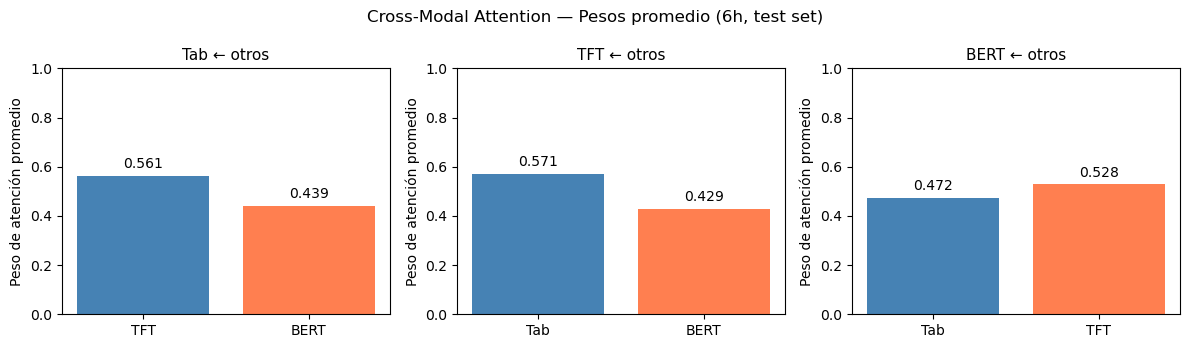

[17:43:29] Guardada: ../experiments/fusion_multimodal/crossattn_tabnet_weights_6h.png


In [10]:
import matplotlib.pyplot as plt

X_tab, X_tft, X_bert, has_note, y = fusion_6h["test"]
loader_te = DataLoader(
    TensorDataset(torch.from_numpy(X_tab), torch.from_numpy(X_tft),
                  torch.from_numpy(X_bert), torch.from_numpy(has_note),
                  torch.from_numpy(y)),
    batch_size=1024
)
models["6h"].eval()
# Acumular pesos de atención por modalidad
w_tab_all, w_tft_all, w_bert_all = [], [], []
with torch.no_grad():
    for X_tab_b, X_tft_b, X_bert_b, hn_b, _ in loader_te:
        _, aw = models["6h"](X_tab_b.to(DEVICE), X_tft_b.to(DEVICE), X_bert_b.to(DEVICE), hn_b.to(DEVICE))
        w_tab_all.append(aw["tab"].cpu().numpy())    # [B, 2]: peso sobre (tft, bert)
        w_tft_all.append(aw["tft"].cpu().numpy())    # [B, 2]: peso sobre (tab, bert)
        w_bert_all.append(aw["bert"].cpu().numpy())  # [B, 2]: peso sobre (tab, tft)

w_tab  = np.concatenate(w_tab_all,  axis=0).mean(0)   # [2]
w_tft  = np.concatenate(w_tft_all,  axis=0).mean(0)   # [2]
w_bert = np.concatenate(w_bert_all, axis=0).mean(0)   # [2]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
pairs = [
    ("Tab ← otros",  w_tab,  ["TFT", "BERT"]),
    ("TFT ← otros",  w_tft,  ["Tab", "BERT"]),
    ("BERT ← otros", w_bert, ["Tab", "TFT"]),
]
for ax, (title, w, labels) in zip(axes, pairs):
    bars = ax.bar(labels, w, color=["steelblue", "coral"])
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Peso de atención promedio")
    for bar, val in zip(bars, w):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Cross-Modal Attention — Pesos promedio (6h, test set)", fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / "crossattn_tabnet_weights_6h.png", dpi=150, bbox_inches="tight")
plt.show()
log(f"Guardada: {OUT_DIR / 'crossattn_tabnet_weights_6h.png'}")

## Ablación: rama tabular sin codificador

¿Aporta el codificador de TabNet una representación más útil para la fusión que las 99
características originales sin comprimir? Para aislar la pregunta se entrena la misma red,
con idénticos hiperparámetros y semilla, sustituyendo únicamente la rama tabular: el
vector de 99 características (imputación por mediana + *z-score*, ajustados sobre el
conjunto de entrenamiento) entra directamente en la proyección lineal de la red.

In [11]:
def build_fusion_dataset_raw(feats_df, tft_ids, tft_repr, bert_lookup, feature_cols):
    """Como build_fusion_dataset, pero la rama tabular es el vector de 99 características."""
    train_df = feats_df.filter(pl.col("split") == "train")
    X_tr_raw = train_df.select(feature_cols).to_pandas().astype(float).values
    imp_tab  = SimpleImputer(strategy="median").fit(X_tr_raw)
    sc_tab   = StandardScaler().fit(imp_tab.transform(X_tr_raw))
    tab_lookup   = {r.pop("stay_id"): np.array(
        [r[c] if r[c] is not None else np.nan for c in feature_cols], dtype=float)
        for r in feats_df.select(["stay_id"] + feature_cols).to_dicts()}
    label_lookup = dict(zip(feats_df["stay_id"].to_list(), feats_df["sepsis"].to_list()))
    result = {}
    for split in ["train", "val", "test"]:
        ids = tft_ids[split]
        X_tab_raw = np.stack([tab_lookup.get(int(sid), np.full(len(feature_cols), np.nan))
                              for sid in ids])
        X_tab  = sc_tab.transform(imp_tab.transform(X_tab_raw)).astype(np.float32)
        X_tft  = tft_repr[split].astype(np.float32)
        X_bert, has_note = get_bert_arrays(ids, bert_lookup)
        y = np.array([label_lookup.get(int(sid), 0) for sid in ids], dtype=np.int64)
        result[split] = (X_tab, X_tft, X_bert, has_note, y)
    return result


log("Ablación — ensamblando datasets con el vector de 99 características ...")
raw_6h  = build_fusion_dataset_raw(feats_6h,  tft_ids_6h,  tft_repr_6h,  bert_lookup_6h,  FEATURE_COLS)
raw_12h = build_fusion_dataset_raw(feats_12h, tft_ids_12h, tft_repr_12h, bert_lookup_12h, FEATURE_COLS)

models_abl, res_abl_val, res_abl_test = {}, {}, {}
for horizon, data in [("6h", raw_6h), ("12h", raw_12h)]:
    log(f"Ablación — entrenando con rama tabular de 99d — {horizon} ...")
    torch.manual_seed(SEED); np.random.seed(SEED)
    models_abl[horizon], _ = train_fusion(data, get_pw(data))
    res_abl_val[horizon]  = evaluate(models_abl[horizon], data, "val",  f"ablación 99d {horizon} (val)")
    res_abl_test[horizon] = evaluate(models_abl[horizon], data, "test", f"ablación 99d {horizon} (test)")

[17:43:29] Ablación — ensamblando datasets con el vector de 99 características ...


[17:43:33] Ablación — entrenando con rama tabular de 99d — 6h ...


  Epoch  10 | val AUROC=0.8927


  Early stopping en epoch 17
  Mejor val AUROC: 0.9114
  ablación 99d 6h (val)               AUROC=0.9114  AUPRC=0.6786  Sens@Spec90=0.7347


  ablación 99d 6h (test)              AUROC=0.9275  AUPRC=0.7240  Sens@Spec90=0.7638
[17:43:55] Ablación — entrenando con rama tabular de 99d — 12h ...


  Epoch  10 | val AUROC=0.8796


  Early stopping en epoch 16
  Mejor val AUROC: 0.8982


  ablación 99d 12h (val)              AUROC=0.8982  AUPRC=0.6590  Sens@Spec90=0.7131
  ablación 99d 12h (test)             AUROC=0.9264  AUPRC=0.7334  Sens@Spec90=0.7730


In [12]:
print("=" * 88)
print("  ABLACIÓN DE LA RAMA TABULAR — codificador TabNet (32d) vs 99d sin comprimir")
print("=" * 88)
print(f"{'Horiz.':<8} {'Rama tabular':<18} {'AUROC val':>10} {'AUROC test':>11} {'AUPRC test':>11} {'Sens@90':>9}")
print("-" * 88)
for horizon in ["6h", "12h"]:
    m, a   = res_test[horizon], res_abl_test[horizon]
    mv, av = res_val[horizon],  res_abl_val[horizon]
    print(f"{horizon:<8} {'TabNet (32d)':<18} {mv['auroc']:>10.4f} {m['auroc']:>11.4f} "
          f"{m['auprc']:>11.4f} {m['sens_at_spec90']:>9.4f}")
    print(f"{'':<8} {'99d sin comprimir':<18} {av['auroc']:>10.4f} {a['auroc']:>11.4f} "
          f"{a['auprc']:>11.4f} {a['sens_at_spec90']:>9.4f}")
    print(f"{'':<8} {'delta (TabNet-99d)':<18} {mv['auroc']-av['auroc']:>+10.4f} "
          f"{m['auroc']-a['auroc']:>+11.4f}")
    print("-" * 88)

  ABLACIÓN DE LA RAMA TABULAR — codificador TabNet (32d) vs 99d sin comprimir
Horiz.   Rama tabular        AUROC val  AUROC test  AUPRC test   Sens@90
----------------------------------------------------------------------------------------
6h       TabNet (32d)           0.8969      0.9122      0.7018    0.7290
         99d sin comprimir      0.9114      0.9275      0.7240    0.7638
         delta (TabNet-99d)    -0.0145     -0.0153
----------------------------------------------------------------------------------------
12h      TabNet (32d)           0.8925      0.9165      0.7246    0.7587
         99d sin comprimir      0.8982      0.9264      0.7334    0.7730
         delta (TabNet-99d)    -0.0057     -0.0099
----------------------------------------------------------------------------------------


In [13]:
for horizon in ["6h", "12h"]:
    torch.save(models[horizon].state_dict(),     OUT_DIR / f"fusion_{horizon}.pt")
    torch.save(models_abl[horizon].state_dict(), OUT_DIR / f"fusion_ablacion_99d_{horizon}.pt")

results = {
    "architecture": "Fusión multimodal cross-modal: TabNet(32) + TFT(64) + Bio_ClinicalBERT(768)",
    "tab_branch": "TabNet encoder (entrada de final_mapping), z-scored con estadísticos de train",
    "val":  res_val,
    "test": res_test,
    "ablacion_raw99": {"val": res_abl_val, "test": res_abl_test},
}
with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
log("Completado.")

{
  "architecture": "Fusi\u00f3n multimodal cross-modal: TabNet(32) + TFT(64) + Bio_ClinicalBERT(768)",
  "tab_branch": "TabNet encoder (entrada de final_mapping), z-scored con estad\u00edsticos de train",
  "val": {
    "6h": {
      "auroc": 0.8969,
      "auprc": 0.6576,
      "sens_at_spec90": 0.7055
    },
    "12h": {
      "auroc": 0.8925,
      "auprc": 0.6419,
      "sens_at_spec90": 0.6921
    }
  },
  "test": {
    "6h": {
      "auroc": 0.9122,
      "auprc": 0.7018,
      "sens_at_spec90": 0.729
    },
    "12h": {
      "auroc": 0.9165,
      "auprc": 0.7246,
      "sens_at_spec90": 0.7587
    }
  },
  "ablacion_raw99": {
    "val": {
      "6h": {
        "auroc": 0.9114,
        "auprc": 0.6786,
        "sens_at_spec90": 0.7347
      },
      "12h": {
        "auroc": 0.8982,
        "auprc": 0.659,
        "sens_at_spec90": 0.7131
      }
    },
    "test": {
      "6h": {
        "auroc": 0.9275,
        "auprc": 0.724,
        "sens_at_spec90": 0.7638
      },
      